<a href="https://colab.research.google.com/github/DineshYadav06/AI-based-system-for-recognizing-Indian-cattle-and-buffalo-breeds-/blob/main/Efficient_Net_B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
dataset_path = '/content/drive/MyDrive/Cattle_Breed_workspace/Kaggle_Datasets/cattle_breeds/PNG Breeds'

img_size = 380   # EfficientNetB4 input size
batch_size = 8   # Increase if GPU allows

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8,1.2],
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # VERY IMPORTANT FIX
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())

Found 969 images belonging to 5 classes.
Found 239 images belonging to 5 classes.


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

In [ ]:
base_model = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

base_model.trainable = False

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(num_classes, activation='softmax', dtype='float32')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 169s 916ms/step - accuracy: 0.6024 - loss: 1.0799 - val_accuracy: 0.6025 - val_loss: 0.9739 - learning_rate: 5.0000e-06
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 59s 481ms/step - accuracy: 0.6840 - loss: 0.9110 - val_accuracy: 0.6569 - val_loss: 0.9804 - learning_rate: 5.0000e-06
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 59s 480ms/step - accuracy: 0.6592 - loss: 0.9771 - val_accuracy: 0.6444 - val_loss: 1.0486 - learning_rate: 5.0000e-06
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 58s 474ms/step - accuracy: 0.6987 - loss: 0.8272 - val_accuracy: 0.6527 - val_loss: 1.0564 - learning_rate: 1.5000e-06
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 59s 482ms/step - accuracy: 0.7105 - loss: 0.7973 - val_accuracy: 0.6569 - val_loss: 0.9615 - learning_rate: 1.5000e-06
Epoch 6/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 59s 486ms/step - accuracy: 0.7043 - loss: 0.9056 - val_accuracy: 0.6318 - val_loss: 1.0186 - learning_rate: 1.5000e-06
Epoch 7/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 84s 5

In [ ]:
val_generator.reset()

y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

print(classification_report(y_true, y_pred_classes, target_names=class_names))

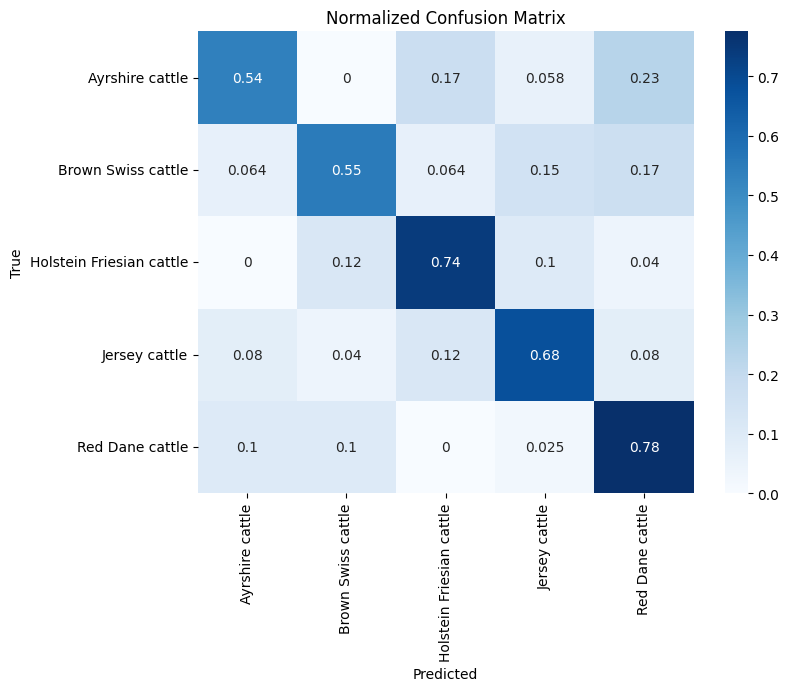

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized,
            annot=True,
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()